# Notebook 7 — Courbes IDF (Intensité-Durée-Fréquence)
## Méthode Montana — Station de Kara, Togo

---

## Objectif

Ce notebook est le **livrable final** du pipeline. Il produit les **courbes IDF**  
utilisées pour le dimensionnement d'ouvrages hydrauliques à Kara.

### Qu'est-ce qu'une courbe IDF ?

Une courbe IDF représente la relation entre :
- **I** : Intensité de précipitation (mm/h)
- **D** : Durée de l'événement (min)
- **T** : Période de retour (ans) — fréquence de dépassement

### Formule de Montana

La formule de Montana est un modèle puissance standard en hydrologie urbaine :

$$I(D, T) = a(T) \times D^{b(T)}$$

où :
- $I$ = intensité (mm/h)
- $D$ = durée (min)
- $a(T)$ = paramètre dépendant de la période de retour
- $b(T)$ = exposant négatif (typiquement -0.4 à -0.7)

### Méthodologie

1. **Maxima annuels par durée** : pour chaque durée, calcul du max annuel d'intensité
2. **Ajustement Gumbel par durée** : calcul des valeurs de retour pour chaque durée
3. **Tableau IDF** : matrice `[durée × période de retour]` d'intensités
4. **Ajustement Montana** : régression non linéaire `I = a × D^b` par `curve_fit`
5. **IC Bootstrap** : estimation de l'incertitude sur les courbes IDF

### Livrables

| Fichier | Contenu |
|---------|--------|
| `data/tableau_idf.csv` | Matrice intensités [durée × T] |
| `data/parametres_idf.csv` | Paramètres Montana [T, a, b, R²] |
| `figures/n7/fig1_courbes_idf.png` | Courbes IDF (axes log-log) |
| `figures/n7/fig2_parametres_montana.png` | Évolution de a(T) et b(T) |
| `figures/n7/fig3_idf_enveloppe.png` | Enveloppe IC 95% |

---
**Auteur :** AY2K  
**Encadreur :** Prof. Titembaye Donald  
**Établissement :** École Polytechnique de Lomé (EPL)  
**Projet :** Modélisation des courbes IDF — Station de Kara, Nord Togo  

## 0. Configuration et imports

In [1]:
import os
import warnings

warnings.filterwarnings('ignore')

NB = 'n7'
FIG_DIR = f'figures/{NB}'
os.makedirs(FIG_DIR, exist_ok=True)

print(f'Répertoire figures : {FIG_DIR}')

Répertoire figures : figures/n7


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats as sp_stats
from scipy.optimize import curve_fit

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'grid.linewidth':   0.6,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'figure.dpi':       100,
})

print('Imports chargés')

Imports chargés


---
## Section 1 — Chargement des données

In [3]:
df_pg = pd.read_csv('data/pluviographe_clean.csv', parse_dates=['date'])
df_serie = pd.read_csv('data/serie_complete.csv', parse_dates=['date'])

DUREES = sorted(df_pg['duree_min'].unique())
PERIODES_RETOUR = [2, 5, 10, 20, 50, 100]

print(f'Pluviographe   : {len(df_pg)} lignes | Durées : {len(DUREES)} valeurs uniques')
print(f'Série complète : {len(df_serie)} lignes | {df_serie.date.min().date()} → {df_serie.date.max().date()}')
print(f'Périodes de retour : {PERIODES_RETOUR} ans')

Pluviographe   : 1115 lignes | Durées : 86 valeurs uniques
Série complète : 3012 lignes | 1980-01-21 → 2014-11-30
Périodes de retour : [2, 5, 10, 20, 50, 100] ans


---
## Section 2 — Maxima annuels par durée

Pour chaque durée disponible, on calcule le **maximum annuel** d'intensité.  
On ne conserve que les durées ayant **au moins 3 années** de données pour  
permettre un ajustement statistique fiable.

In [4]:
df_pg['annee'] = df_pg['date'].dt.year

maxima_par_duree = {}
for duree in DUREES:
    df_d = df_pg[df_pg.duree_min == duree]
    max_ann = df_d.groupby('annee')['intensite_mm_h'].max().dropna()
    if len(max_ann) >= 3:
        maxima_par_duree[duree] = max_ann.values
    else:
        print(f'  Durée {duree} min : seulement {len(max_ann)} années — ignorée')

print(f'\n{len(maxima_par_duree)} durées avec données suffisantes (≥ 3 ans)')
for d, vals in maxima_par_duree.items():
    print(f'  {d:>6.0f} min : {len(vals)} années, max={vals.max():.1f} mm/h')

  Durée 1.0 min : seulement 1 années — ignorée
  Durée 2.0 min : seulement 2 années — ignorée
  Durée 4.0 min : seulement 1 années — ignorée
  Durée 5.0 min : seulement 1 années — ignorée
  Durée 124.0 min : seulement 1 années — ignorée
  Durée 128.0 min : seulement 2 années — ignorée
  Durée 134.0 min : seulement 1 années — ignorée
  Durée 148.0 min : seulement 2 années — ignorée
  Durée 178.0 min : seulement 2 années — ignorée
  Durée 184.0 min : seulement 1 années — ignorée
  Durée 224.0 min : seulement 2 années — ignorée
  Durée 226.0 min : seulement 1 années — ignorée
  Durée 248.0 min : seulement 2 années — ignorée
  Durée 264.0 min : seulement 1 années — ignorée
  Durée 294.0 min : seulement 2 années — ignorée
  Durée 300.0 min : seulement 1 années — ignorée
  Durée 312.0 min : seulement 2 années — ignorée
  Durée 318.0 min : seulement 1 années — ignorée
  Durée 324.0 min : seulement 2 années — ignorée
  Durée 336.0 min : seulement 2 années — ignorée
  Durée 348.0 min : seulemen

---
## Section 3 — Ajustement Gumbel par durée

Pour chaque durée, on ajuste une loi de Gumbel sur les maxima annuels  
et on calcule les intensités pour les périodes de retour standards.

### Pourquoi Gumbel ?

Gumbel est la loi standard pour les maxima annuels en hydrologie.  
Elle est recommandée par la OMM (Organisation Météorologique Mondiale).

In [5]:
# Dictionnaire : idf[duree][T] = intensité (mm/h)
idf_table = {}

for duree, vals in maxima_par_duree.items():
    try:
        params = sp_stats.gumbel_r.fit(vals)
        idf_table[duree] = {}
        for T in PERIODES_RETOUR:
            p = 1 - 1/T
            idf_table[duree][T] = sp_stats.gumbel_r.ppf(p, *params)
    except Exception as e:
        print(f'Gumbel non convergée pour durée={duree} min : {e}')
        # Fallback : quantiles empiriques
        idf_table[duree] = {}
        for T in PERIODES_RETOUR:
            p = min(1 - 1/T, 0.99)
            idf_table[duree][T] = np.quantile(vals, p)

# Tableau IDF
df_idf = pd.DataFrame(idf_table).T
df_idf.index.name = 'duree_min'
df_idf.columns.name = 'T (ans)'

print('=== Tableau IDF — Intensités (mm/h) ===')
print(df_idf.round(1).to_string())

=== Tableau IDF — Intensités (mm/h) ===
T (ans)      2      5      10     20     50     100
duree_min                                          
3.0         65.5  125.9  166.0  204.4  254.1  291.3
6.0        109.3  225.8  303.0  377.0  472.8  544.6
12.0        35.9   58.0   72.6   86.7  104.8  118.4
18.0        30.2   51.4   65.4   78.9   96.4  109.5
24.0        29.5   51.9   66.6   80.8   99.2  112.9
30.0        27.6   40.8   49.5   57.8   68.7   76.8
36.0        24.4   42.5   54.5   66.0   80.8   92.0
42.0        19.0   30.4   38.0   45.2   54.6   61.7
48.0        16.7   27.8   35.2   42.2   51.3   58.1
54.0        18.7   27.8   33.9   39.7   47.2   52.9
60.0        12.0   21.3   27.4   33.3   40.9   46.6
66.0        13.7   19.6   23.6   27.4   32.3   35.9
72.0        13.5   23.1   29.5   35.7   43.6   49.6
78.0        12.9   19.7   24.3   28.6   34.2   38.5
84.0         5.1    8.8   11.2   13.6   16.6   18.9
90.0         6.1    9.2   11.2   13.2   15.8   17.7
96.0        16.5   26.9 

---
## Section 4 — Ajustement Montana (I = a × D^b)

La formule de Montana est ajustée par **moindres carrés non linéaires** (`curve_fit`)  
pour chaque période de retour.

### Paramètres

- **a** : coefficient de proportionnalité (augmente avec T)
- **b** : exposant négatif (typiquement -0.4 à -0.7)

### Fallback log-log

Si `curve_fit` ne converge pas, on utilise la régression linéaire en log-log :  
$\log(I) = \log(a) + b \cdot \log(D)$

In [6]:
def montana(D, a, b):
    """Formule de Montana : I = a * D^b."""
    return a * np.power(D, b)

parametres_montana = []
durees_arr = np.array(sorted(idf_table.keys()), dtype=float)

for T in PERIODES_RETOUR:
    intensites = np.array([idf_table[d][T] for d in durees_arr if T in idf_table.get(d, {})])
    durees_fit = np.array([d for d in durees_arr if T in idf_table.get(d, {})])
    
    if len(durees_fit) < 3:
        print(f'T={T} ans : données insuffisantes ({len(durees_fit)} points)')
        continue
    
    try:
        popt, pcov = curve_fit(montana, durees_fit, intensites,
                               p0=[100.0, -0.5], maxfev=5000,
                               bounds=([0, -2], [10000, 0]))
        a_fit, b_fit = popt
        I_pred = montana(durees_fit, a_fit, b_fit)
        ss_res = np.sum((intensites - I_pred)**2)
        ss_tot = np.sum((intensites - intensites.mean())**2)
        r2 = 1 - ss_res/ss_tot if ss_tot > 0 else 0
        parametres_montana.append({'T': T, 'a': round(a_fit, 3),
                                   'b': round(b_fit, 4), 'R²': round(r2, 4)})
        print(f'T={T:3d} ans : a={a_fit:.3f}, b={b_fit:.4f}, R²={r2:.4f}')
    except Exception as e:
        # Fallback : régression log-log
        try:
            slope, intercept, r, _, _ = sp_stats.linregress(
                np.log(durees_fit), np.log(intensites))
            a_fit = np.exp(intercept)
            b_fit = slope
            parametres_montana.append({'T': T, 'a': round(a_fit, 3),
                                       'b': round(b_fit, 4), 'R²': round(r**2, 4)})
            print(f'T={T:3d} ans : a={a_fit:.3f}, b={b_fit:.4f} (log-log fallback)')
        except:
            print(f'T={T} ans : échec complet')

df_montana = pd.DataFrame(parametres_montana)
print(f'\n=== Paramètres Montana ===')
print('Formule : I(D,T) = a(T) × D^b(T)  [I en mm/h, D en min]')
print(df_montana.to_string(index=False))

T=  2 ans : a=177.181, b=-0.5989, R²=0.7769
T=  5 ans : a=365.973, b=-0.6464, R²=0.7355
T= 10 ans : a=491.902, b=-0.6596, R²=0.7237
T= 20 ans : a=612.938, b=-0.6676, R²=0.7166
T= 50 ans : a=769.762, b=-0.6744, R²=0.7105
T=100 ans : a=887.349, b=-0.6780, R²=0.7073

=== Paramètres Montana ===
Formule : I(D,T) = a(T) × D^b(T)  [I en mm/h, D en min]
  T       a       b     R²
  2 177.181 -0.5989 0.7769
  5 365.973 -0.6464 0.7355
 10 491.902 -0.6596 0.7237
 20 612.938 -0.6676 0.7166
 50 769.762 -0.6744 0.7105
100 887.349 -0.6780 0.7073


---
## Section 5 — Figures

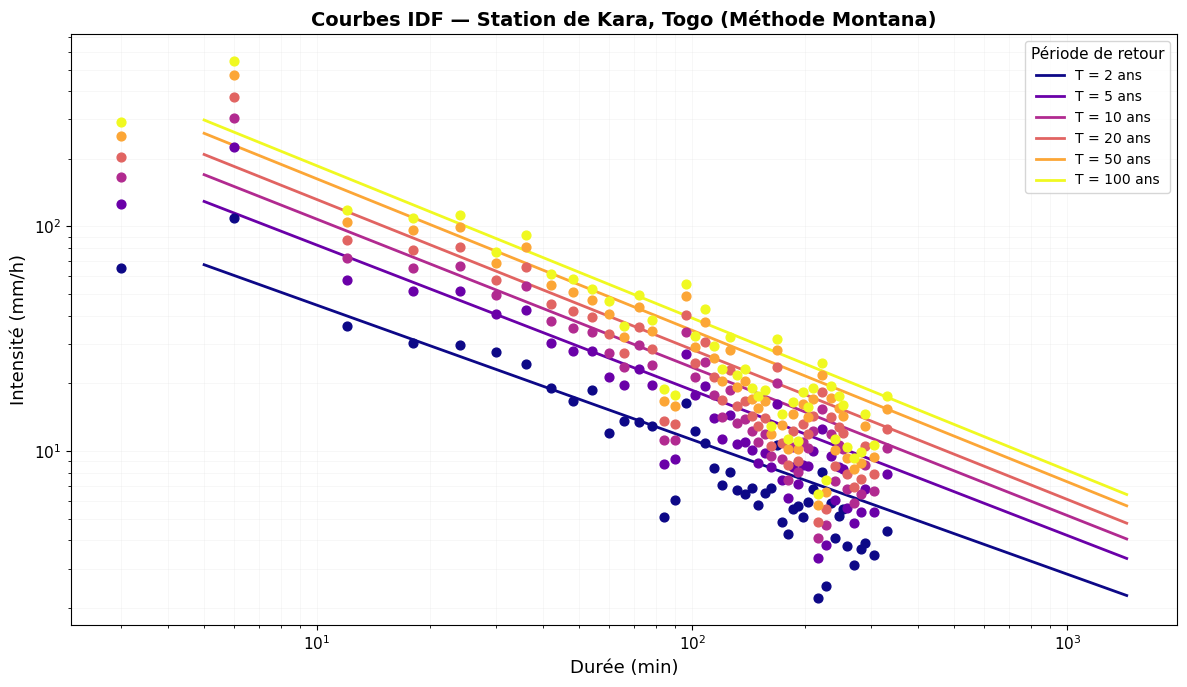

fig1 sauvegardée


In [7]:
# ==============================================================================
# FIGURE 1 — Courbes IDF principales (axes log-log)
# ==============================================================================

colors_T = cm.get_cmap('plasma', len(PERIODES_RETOUR))
D_plot = np.logspace(np.log10(5), np.log10(1440), 200)

fig, ax = plt.subplots(figsize=(12, 7))

for i, row in df_montana.iterrows():
    T = int(row['T'])
    I_curve = montana(D_plot, row['a'], row['b'])
    ax.plot(D_plot, I_curve, '-', color=colors_T(i/len(df_montana)),
            linewidth=2, label=f'T = {T} ans')
    # Points observés
    obs_d = [d for d in durees_arr if T in idf_table.get(d, {})]
    obs_I = [idf_table[d][T] for d in obs_d]
    ax.scatter(obs_d, obs_I, color=colors_T(i/len(df_montana)), s=40, zorder=5)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Durée (min)', fontsize=13)
ax.set_ylabel('Intensité (mm/h)', fontsize=13)
ax.set_title('Courbes IDF — Station de Kara, Togo (Méthode Montana)',
             fontsize=14, fontweight='bold')
ax.legend(title='Période de retour', fontsize=10, title_fontsize=11)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig1_courbes_idf.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig1 sauvegardée')

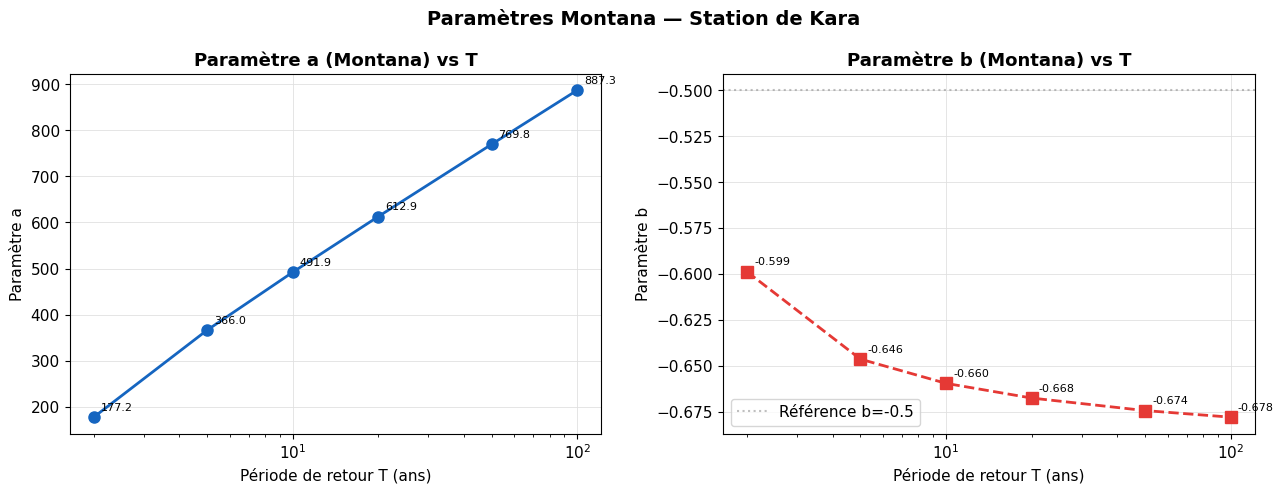

fig2 sauvegardée


In [8]:
# ==============================================================================
# FIGURE 2 — Évolution des paramètres a et b
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax1 = axes[0]
ax1.plot(df_montana['T'], df_montana['a'], 'o-', color='#1565C0', linewidth=2, markersize=8)
ax1.set_xlabel('Période de retour T (ans)')
ax1.set_ylabel('Paramètre a')
ax1.set_title('Paramètre a (Montana) vs T', fontweight='bold')
ax1.set_xscale('log')
for _, row in df_montana.iterrows():
    ax1.annotate(f'{row["a"]:.1f}', (row['T'], row['a']),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)

ax2 = axes[1]
ax2.plot(df_montana['T'], df_montana['b'], 's--', color='#E53935', linewidth=2, markersize=8)
ax2.set_xlabel('Période de retour T (ans)')
ax2.set_ylabel('Paramètre b')
ax2.set_title('Paramètre b (Montana) vs T', fontweight='bold')
ax2.set_xscale('log')
ax2.axhline(-0.5, color='grey', linestyle=':', alpha=0.5, label='Référence b=-0.5')
ax2.legend()
for _, row in df_montana.iterrows():
    ax2.annotate(f'{row["b"]:.3f}', (row['T'], row['b']),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)

plt.suptitle('Paramètres Montana — Station de Kara', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig2_parametres_montana.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig2 sauvegardée')

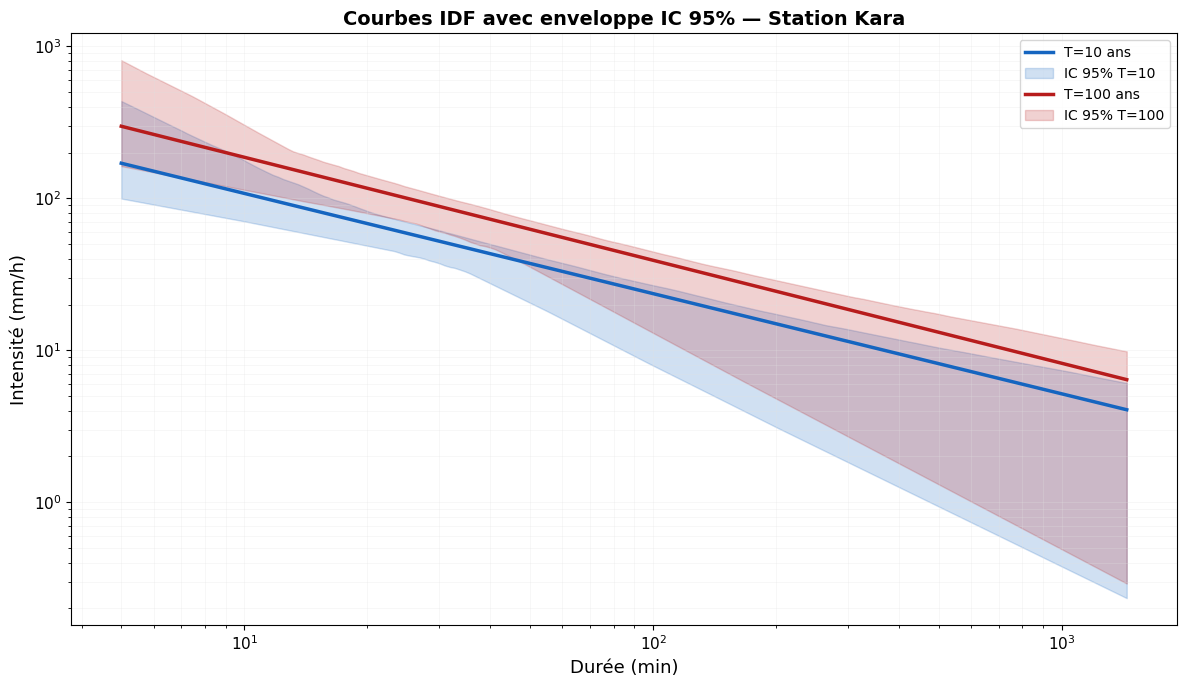

fig3 sauvegardée


In [9]:
# ==============================================================================
# FIGURE 3 — Enveloppe IC 95% (Bootstrap)
# ==============================================================================

T_ref_list = [10, 100]
N_BOOT = 300

fig, ax = plt.subplots(figsize=(12, 7))
colors_env = {'10': '#1565C0', '100': '#B71C1C'}

for T_ref in T_ref_list:
    row_mont = df_montana[df_montana['T'] == T_ref]
    if len(row_mont) == 0:
        continue
    a_ref = row_mont.iloc[0]['a']
    b_ref = row_mont.iloc[0]['b']
    col = colors_env.get(str(T_ref), 'steelblue')

    # Courbe principale
    I_main = montana(D_plot, a_ref, b_ref)
    ax.plot(D_plot, I_main, '-', color=col, linewidth=2.5, label=f'T={T_ref} ans')

    # Bootstrap
    I_boot = np.zeros((N_BOOT, len(D_plot)))
    for b_i in range(N_BOOT):
        sampled_durees = []
        sampled_intensites = []
        for d in durees_arr:
            if T_ref in idf_table.get(d, {}):
                max_d = maxima_par_duree.get(d, None)
                if max_d is not None and len(max_d) > 0:
                    sample = np.random.choice(max_d, size=len(max_d), replace=True)
                    try:
                        p_gum = sp_stats.gumbel_r.fit(sample)
                        i_boot = sp_stats.gumbel_r.ppf(1-1/T_ref, *p_gum)
                        sampled_durees.append(d)
                        sampled_intensites.append(i_boot)
                    except:
                        pass
        if len(sampled_durees) >= 3:
            try:
                popt_b, _ = curve_fit(montana, sampled_durees, sampled_intensites,
                                      p0=[a_ref, b_ref], maxfev=2000,
                                      bounds=([0, -2], [10000, 0]))
                I_boot[b_i] = montana(D_plot, *popt_b)
            except:
                I_boot[b_i] = I_main
        else:
            I_boot[b_i] = I_main

    I_lo = np.percentile(I_boot, 2.5, axis=0)
    I_hi = np.percentile(I_boot, 97.5, axis=0)
    ax.fill_between(D_plot, I_lo, I_hi, alpha=0.2, color=col, label=f'IC 95% T={T_ref}')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Durée (min)', fontsize=13)
ax.set_ylabel('Intensité (mm/h)', fontsize=13)
ax.set_title('Courbes IDF avec enveloppe IC 95% — Station Kara',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig3_idf_enveloppe.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig3 sauvegardée')

---
## Section 6 — Export des résultats

In [10]:
# Tableau IDF complet
df_idf_export = df_idf.copy()
df_idf_export.index.name = 'duree_min'
df_idf_export.to_csv('data/tableau_idf.csv')
print('data/tableau_idf.csv exporté')

# Paramètres Montana
df_montana.to_csv('data/parametres_idf.csv', index=False)
print('data/parametres_idf.csv exporté')

print(f'\n=== TABLEAU IDF FINAL (mm/h) ===')
print(df_idf.round(1).to_string())

print(f'\n=== PARAMÈTRES MONTANA ===')
print('Formule : I(D,T) = a(T) × D^b(T)  [I en mm/h, D en min]')
print(df_montana.to_string(index=False))

data/tableau_idf.csv exporté
data/parametres_idf.csv exporté

=== TABLEAU IDF FINAL (mm/h) ===
T (ans)      2      5      10     20     50     100
duree_min                                          
3.0         65.5  125.9  166.0  204.4  254.1  291.3
6.0        109.3  225.8  303.0  377.0  472.8  544.6
12.0        35.9   58.0   72.6   86.7  104.8  118.4
18.0        30.2   51.4   65.4   78.9   96.4  109.5
24.0        29.5   51.9   66.6   80.8   99.2  112.9
30.0        27.6   40.8   49.5   57.8   68.7   76.8
36.0        24.4   42.5   54.5   66.0   80.8   92.0
42.0        19.0   30.4   38.0   45.2   54.6   61.7
48.0        16.7   27.8   35.2   42.2   51.3   58.1
54.0        18.7   27.8   33.9   39.7   47.2   52.9
60.0        12.0   21.3   27.4   33.3   40.9   46.6
66.0        13.7   19.6   23.6   27.4   32.3   35.9
72.0        13.5   23.1   29.5   35.7   43.6   49.6
78.0        12.9   19.7   24.3   28.6   34.2   38.5
84.0         5.1    8.8   11.2   13.6   16.6   18.9
90.0         6.1    9

---
## Résumé final du pipeline

| Notebook | Entrée | Sortie |
|----------|--------|--------|
| n1 | `KARA PLUIE JOURNALIERE.xls` | 5 figures (exploration) |
| n2 | `INTENSITES DE PLUIE -KARA.xlsx` | 6+ figures (exploration) |
| n3 | Fichiers bruts | `pluviometre_clean.csv`, `pluviographe_clean.csv` |
| n4 | CSV nettoyés | `tableau_entrainement.csv` |
| n5 | `tableau_entrainement.csv` | `serie_complete.csv` (1980–présent) |
| n6 | `serie_complete.csv` | Valeurs de retour, loi retenue |
| n7 | `pluviographe_clean.csv` + `serie_complete.csv` | `tableau_idf.csv`, `parametres_idf.csv` |

### Formule Montana retenue

**I(D, T) = a(T) × D^b(T)** où I en mm/h, D en min  
Les paramètres a et b sont dans `data/parametres_idf.csv` pour T = 2, 5, 10, 20, 50, 100 ans.

---
*Fin du Notebook 7 — Pipeline IDF complet*